<a href="https://colab.research.google.com/github/nabinjoshi54/lis5693/blob/main/lab-6/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: Text Networks

In this lab, I use a subset of my lab-5 dataset on batteries and space-related research articles to build and analyze a text network. I preprocess the text, construct a document-term network, identify important nodes using degree and BiRank, create a term-term projection network, examine betweenness, and analyze clusters to identify themes in the corpus.


## Task 1: Load and Prepare the Dataset

For this task, I reused the dataset from lab-5 and kept only 20 articles, as instructed. I combined the `Title` and `Abstract` columns into a single text field so that each document includes both a short summary and a more detailed description. This combined text is used to create the corpus for text network analysis.

In [1]:
!pip install textnets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.2/212.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 136.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 135.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import textnets as tn
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import nltk

from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
tn.params["seed"] = 42

In [4]:
url = "https://raw.githubusercontent.com/nabinjoshi54/lis5693/refs/heads/main/lab-6/lab5-batteries-and-space.csv"
df = pd.read_csv(url)

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (1000, 32)


,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,PMID,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour
0,000-277-169-899-878,WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES,NaN,1970.0,book chapter,Research and Development in Non-Mechanical Ele...,NaN,Elsevier,NaN,D.L. Douglas; R.E. Biddick; J.B. Ockerman,...,NaN,10.1016/b978-0-08-013435-2.50011-6,2234449575,NaN,0,026-727-716-648-058; 118-148-506-040-617,3,False,NaN,NaN
1,000-296-458-948-553,Digitally controlled autonomous Li-ion active ...,NaN,2014.0,conference proceedings article,2014 International Conference on Advances in E...,NaN,IEEE,NaN,G Rishivathsala; S Ananda; V. Sreekumar; Nitin...,...,NaN,10.1109/icaecc.2014.7002466,2541639867,NaN,0,029-655-612-502-395; 066-402-048-809-762; 073-...,4,False,NaN,NaN
2,000-395-893-043-269,Space systems � Lithium ion battery for space ...,2016-03-19,2016.0,standard,NaN,NaN,BSI British Standards,NaN,NaN,...,NaN,10.3403/30296384u,NaN,NaN,0,NaN,0,False,NaN,NaN
3,000-550-445-902-514,Cost-Benefit Analysis Model of Single and Hybr...,NaN,2014.0,journal article,Applied Mechanics and Materials,16627482,"Trans Tech Publications, Ltd.",NaN,Yi Feng; Lei Jun Shao; Bang Ling Zhang; Jing Y...,...,NaN,10.4028/www.scientific.net/amm.672-674.503,1999071943,NaN,0,053-147-224-892-52X; 066-432-448-842-155; 095-...,0,False,NaN,NaN
4,000-621-072-737-768,The 2000 NASA Aerospace Battery Workshop,2001-03-01,2001.0,NaN,NaN,NaN,NaN,NaN,Jeffrey C. Brewer,...,NaN,NaN,2801440225,NaN,0,NaN,0,False,NaN,NaN


In [5]:
# Keep only 20 articles
df = df.iloc[:20].copy()

print("Subset shape:", df.shape)
df.head()

Subset shape: (20, 32)


,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,PMID,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour
0,000-277-169-899-878,WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES,NaN,1970.0,book chapter,Research and Development in Non-Mechanical Ele...,NaN,Elsevier,NaN,D.L. Douglas; R.E. Biddick; J.B. Ockerman,...,NaN,10.1016/b978-0-08-013435-2.50011-6,2234449575,NaN,0,026-727-716-648-058; 118-148-506-040-617,3,False,NaN,NaN
1,000-296-458-948-553,Digitally controlled autonomous Li-ion active ...,NaN,2014.0,conference proceedings article,2014 International Conference on Advances in E...,NaN,IEEE,NaN,G Rishivathsala; S Ananda; V. Sreekumar; Nitin...,...,NaN,10.1109/icaecc.2014.7002466,2541639867,NaN,0,029-655-612-502-395; 066-402-048-809-762; 073-...,4,False,NaN,NaN
2,000-395-893-043-269,Space systems � Lithium ion battery for space ...,2016-03-19,2016.0,standard,NaN,NaN,BSI British Standards,NaN,NaN,...,NaN,10.3403/30296384u,NaN,NaN,0,NaN,0,False,NaN,NaN
3,000-550-445-902-514,Cost-Benefit Analysis Model of Single and Hybr...,NaN,2014.0,journal article,Applied Mechanics and Materials,16627482,"Trans Tech Publications, Ltd.",NaN,Yi Feng; Lei Jun Shao; Bang Ling Zhang; Jing Y...,...,NaN,10.4028/www.scientific.net/amm.672-674.503,1999071943,NaN,0,053-147-224-892-52X; 066-432-448-842-155; 095-...,0,False,NaN,NaN
4,000-621-072-737-768,The 2000 NASA Aerospace Battery Workshop,2001-03-01,2001.0,NaN,NaN,NaN,NaN,NaN,Jeffrey C. Brewer,...,NaN,NaN,2801440225,NaN,0,NaN,0,False,NaN,NaN


In [6]:
# Combine title and abstract
df["text"] = df["Title"].fillna("") + " " + df["Abstract"].fillna("")
df = df[["Title", "Abstract", "text"]].copy()

df.head()

,Title,Abstract,text
0,WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES,NaN,WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES
1,Digitally controlled autonomous Li-ion active ...,The Energy storage is required to support spac...,Digitally controlled autonomous Li-ion active ...
2,Space systems � Lithium ion battery for space ...,NaN,Space systems � Lithium ion battery for space ...
3,Cost-Benefit Analysis Model of Single and Hybr...,The active distribution network is an effectiv...,Cost-Benefit Analysis Model of Single and Hybr...
4,The 2000 NASA Aerospace Battery Workshop,This document contains the proceedings of the ...,The 2000 NASA Aerospace Battery Workshop This ...


## Task 2: Text Preprocessing and Network Size

In this step, I cleaned the text by converting it to lowercase, removing punctuation, numbers, and stopwords, and keeping only meaningful alphabetic words. I also added a small set of custom stopwords to remove general academic words that appear often but do not add much meaning. After preprocessing, I built the document-term network and counted the number of nodes and edges in the dataset.

In [7]:
stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "et", "al", "using", "used", "use", "based", "study", "results",
    "method", "methods", "analysis", "research", "paper", "article",
    "also", "within", "however", "can", "may", "one", "two", "new",
    "show", "shown", "different"
}

stop_words = stop_words.union(custom_stopwords)

In [8]:
def clean_doc(doc):
    doc = str(doc).lower()
    doc = re.sub(r"\d+", " ", doc)
    doc = re.sub(rf"[{re.escape(string.punctuation)}]", " ", doc)
    doc = re.sub(r"\s+", " ", doc).strip()
    tokens = doc.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2 and w.isalpha()]
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["text"].apply(clean_doc)
df = df[df["clean_text"].str.strip() != ""].copy()

df[["Title", "clean_text"]].head()

,Title,clean_text
0,WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES,water activated dry charged batteries
1,Digitally controlled autonomous Li-ion active ...,digitally controlled autonomous ion active cel...
2,Space systems � Lithium ion battery for space ...,space systems lithium ion battery space vehicl...
3,Cost-Benefit Analysis Model of Single and Hybr...,cost benefit model single hybrid energy storag...
4,The 2000 NASA Aerospace Battery Workshop,nasa aerospace battery workshop document conta...


In [12]:
# Create corpus
corpus = tn.Corpus(df["clean_text"], lang="en")
corpus

<Corpus with 20 documents using language model 'en_core_web_sm'>

In [13]:
# Build text network
t = tn.Textnet(corpus.tokenized(), min_docs=1)
t

0docs [00:00, ?docs/s]

Textnet,Docs: 20,Terms: 577,Edges: 843


In [14]:
print("Number of nodes:", len(t.nodes))
print("Number of edges:", len(t.edges))

Number of nodes: 597
Number of edges: 843


In [17]:
nodes_df = pd.DataFrame({
    attr: t.nodes[attr] for attr in t.nodes.attributes()
})
nodes_df.head()

,type,id
0,doc,0
1,doc,1
2,doc,2
3,doc,3
4,doc,4


In [19]:
edges_df = pd.DataFrame({
    attr: t.edges[attr] for attr in t.edges.attributes()
})
edges_df.head()
edges_df.sort_values("weight", ascending=False).head(10)


,weight,cost
0,1.301030,0.876711
1,1.000000,1.000000
2,1.000000,1.000000
3,1.301030,0.876711
4,1.692679,0.768622


After preprocessing and building the bipartite text network, the network contains ___ nodes and ___ edges. The nodes represent both documents and terms, while the edges represent connections between documents and the terms they contain.

## Task 3A: Node Types

The text network is bipartite, which means it contains two different types of nodes: document nodes and term nodes. Document nodes represent the selected research articles, while term nodes represent the important words extracted from the corpus. An edge connects a document to a term when that term appears in the document.

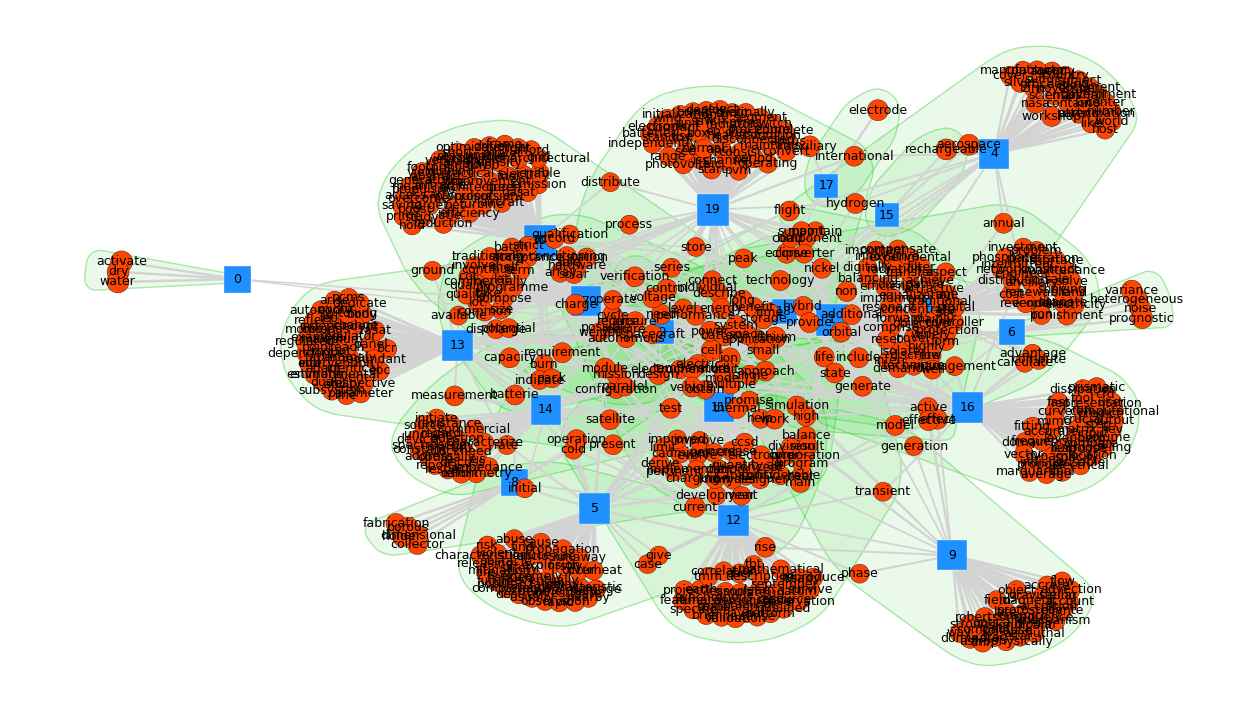

In [20]:
t.plot(
    label_nodes=True,
    show_clusters=True,
    scale_nodes_by="birank",
    scale_edges_by="weight"
)
plt.show()

<Figure size 1400x1200 with 0 Axes>

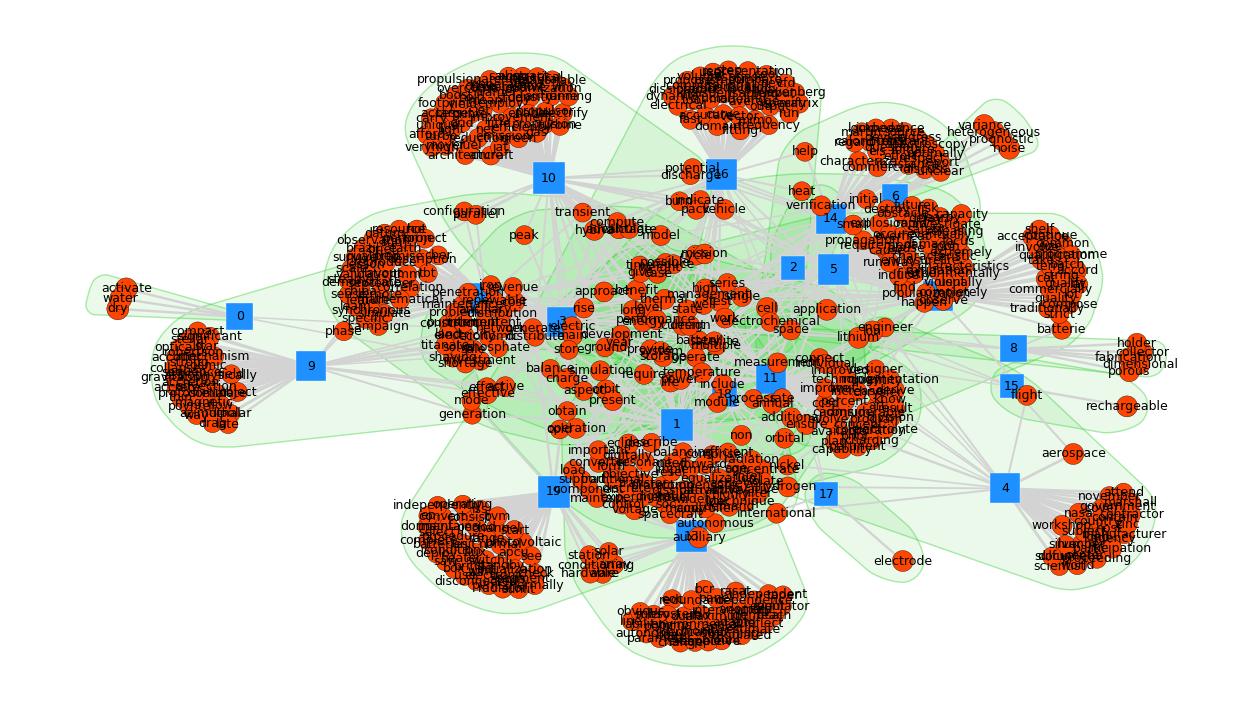

In [21]:
plt.figure(figsize=(14, 12))
t.plot(
    label_nodes=True,
    show_clusters=True,
    scale_nodes_by="birank",
    scale_edges_by="weight"
)
plt.savefig("document_term_network.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 3B: Degree and BiRank

Degree shows how many connections a node has in the network. Nodes with high degree are highly connected and may appear across many documents. BiRank is a bipartite ranking measure that identifies important nodes by considering not only the number of connections, but also the importance of the nodes they connect to. This makes it useful for finding influential terms and documents in the text network.

In [24]:
t.nodes.attributes()

['type', 'id']

In [32]:
import pandas as pd

# Convert nodes to DataFrame
nodes_df = pd.DataFrame({
    attr: t.nodes[attr] for attr in t.nodes.attributes()
})

# Add degree
nodes_df["degree"] = t.graph.degree()

# Add BiRank directly
nodes_df["birank"] = t.birank

# Now get top nodes by degree
top_degree = nodes_df.sort_values("degree", ascending=False).head(10)
top_degree

,type,id,degree,birank
10,doc,10,87,0.036275
1,doc,1,86,0.036225
19,doc,19,83,0.036168
13,doc,13,71,0.033839
16,doc,16,66,0.033973
12,doc,12,60,0.033360
5,doc,5,60,0.033372
11,doc,11,56,0.031753
3,doc,3,48,0.031301
14,doc,14,45,0.030807


In [34]:
top_birank = nodes_df.sort_values("birank", ascending=False).head(10)
top_birank

,type,id,degree,birank
10,doc,10,87,0.036275
1,doc,1,86,0.036225
19,doc,19,83,0.036168
16,doc,16,66,0.033973
13,doc,13,71,0.033839
5,doc,5,60,0.033372
12,doc,12,60,0.033360
4,doc,4,39,0.031928
11,doc,11,56,0.031753
3,doc,3,48,0.031301


The top nodes by degree are the most connected nodes in the network, meaning they appear broadly across the corpus. The top nodes by BiRank are especially important because they are connected to other important nodes. In this dataset, these highly ranked terms help reveal the major concepts discussed across the selected battery and space-related articles.

## Task 3C: Term-Term Projection Network

The term-term projection network connects terms that appear together in the same documents. This network helps reveal which ideas are closely associated in the corpus and provides a more direct picture of conceptual relationships between terms.

In [35]:
words = t.project(node_type=tn.TERM)
words

ProjectedTextnet,Docs: 0,Terms: 577,Edges: 24109


<Figure size 1400x1200 with 0 Axes>

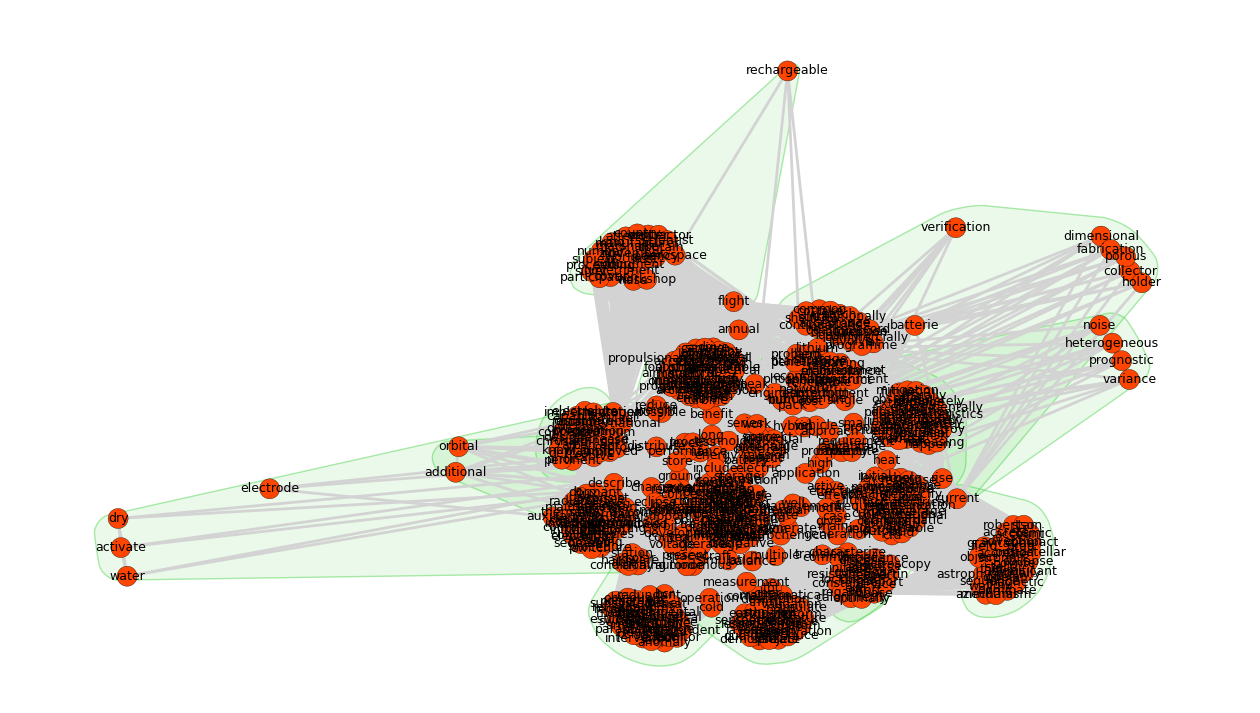

In [36]:
plt.figure(figsize=(14, 12))
words.plot(label_nodes=True, show_clusters=True)
plt.show()

<Figure size 1400x1200 with 0 Axes>

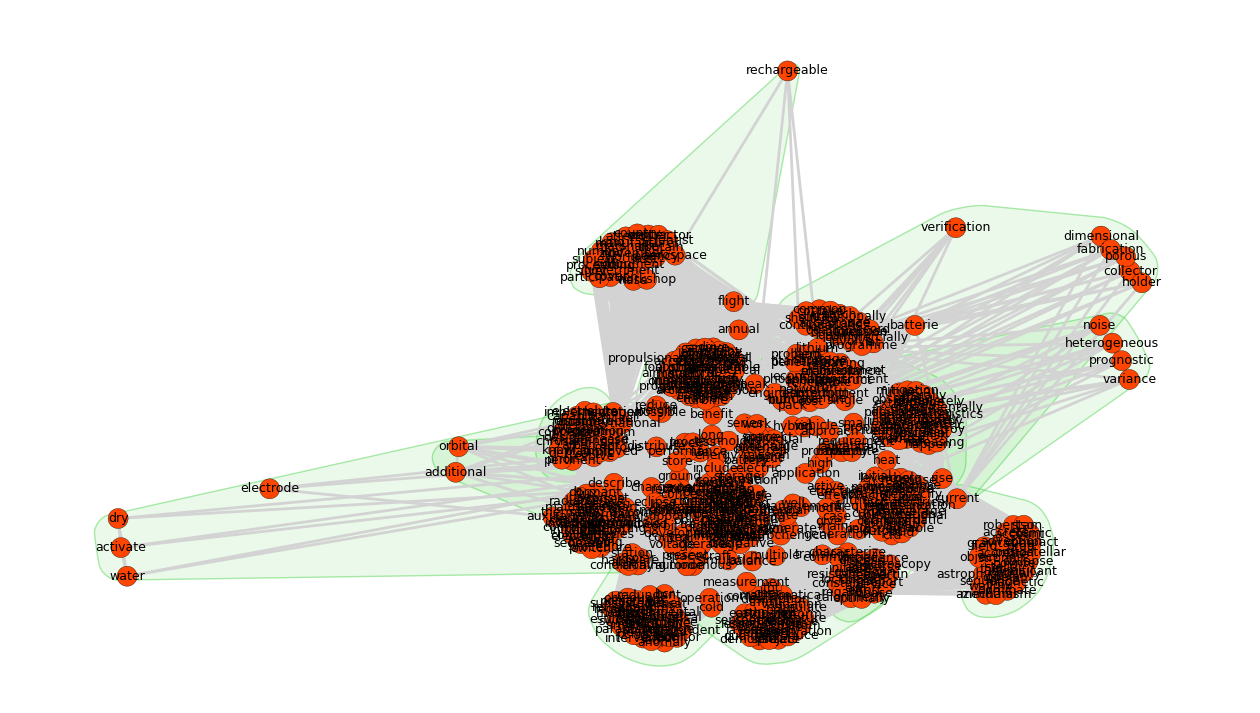

In [37]:
plt.figure(figsize=(14, 12))
words.plot(label_nodes=True, show_clusters=True)
plt.savefig("term_term_network.png", dpi=300, bbox_inches="tight")
plt.show()

The term-term network represents co-occurrence relationships among terms. Two terms are connected when they appear in the same article. This means the network shows which concepts tend to appear together in the corpus and helps reveal the semantic structure of the dataset.

## Task 3E: Strongly Connected Term Pairs

To identify strongly connected term pairs, I examined the highest-weight edges in the term-term projection network. These edges represent pairs of terms that frequently appear together in the same documents.

In [42]:
import pandas as pd

# Build the term-term projection network
words = t.project(node_type=tn.TERM)

# Convert term-term edges to a DataFrame
words_edges_df = pd.DataFrame({
    attr: words.edges[attr] for attr in words.edges.attributes()
})

# Add source and target node indices
words_edges_df["source"] = [e.source for e in words.edges]
words_edges_df["target"] = [e.target for e in words.edges]

# Convert projected-network nodes to a DataFrame
words_nodes_df = pd.DataFrame({
    attr: words.nodes[attr] for attr in words.nodes.attributes()
})

# Use the 'id' column as the term label
term_names = words_nodes_df["id"].tolist()

# Map source and target indices to actual term names
words_edges_df["source_term"] = words_edges_df["source"].map(lambda i: term_names[i])
words_edges_df["target_term"] = words_edges_df["target"].map(lambda i: term_names[i])

# Sort by edge weight to find the strongest term pairs
top_term_pairs = words_edges_df.sort_values("weight", ascending=False).head(10)

# Show the top term pairs
top_term_pairs[["source_term", "target_term", "weight"]]

,source_term,target_term,weight
22243,pvm,start,5.351950
1496,aircraft,jat,4.607222
9153,cost,network,4.445898
17676,iss,pvm,4.445898
21379,photovoltaic,start,4.445898
9162,cost,revenue,4.445898
6227,channel,start,4.445898
21368,photovoltaic,pvm,4.445898
6216,channel,pvm,4.445898
9136,cost,distribution,4.445898


The strong relationships in the term-term network reveal the main conceptual structure of the corpus. In this dataset, the strongest connections are likely related to battery materials, electrochemical behavior, energy storage, and degradation. These relationships show that the selected documents focus on recurring scientific themes in battery and space-related research.

## Task 3G: Betweenness

Betweenness centrality identifies nodes that act as bridges between different parts of the network. Terms with high betweenness are important because they connect multiple themes or clusters, helping show how different ideas in the corpus are linked together.

In [43]:
words.top_betweenness()

,0
electric,8587.000000
operation,5286.000000
hybrid,4338.500000
performance,4129.000000
model,4114.000000
charge,3965.000000
thermal,3952.000000
include,3734.500000
international,3701.000000
phase,3673.333333


In [44]:
papers = t.project(node_type=tn.DOC)
papers.top_betweenness()

,0
19,28.0
1,24.0
7,15.0
4,10.0
16,9.0
10,6.0
5,4.0
11,3.0
3,2.0
13,2.0


The terms with the highest betweenness centrality act as bridges across different thematic areas in the corpus. These terms are useful because they connect multiple clusters and show how broader ideas link specific concepts together.

## Task 4: Cluster Analysis

Clusters in the term-term network represent groups of closely related terms. These clusters can be interpreted as themes in the corpus. By examining the most important terms in each cluster, I can identify the main topics discussed in the selected articles.

In [45]:
terms = t.project(node_type=tn.TERM, connected=True)
terms.top_cluster_nodes()

,nodes,size
cluster,,
0,"[aircraft, jat, green, gas, efficiency, emissi...",78
1,"[start, pvm, photovoltaic, channel, iss, norma...",72
2,"[balancing, converter, efficient, comprise, fo...",62
3,"[capacity, requirement, characterize, commerci...",55
4,"[fitting, domain, vector, mimo, fast, frequenc...",52
5,"[tbt, cber, correlation, tmm, mathematical, de...",51
6,"[propagation, runaway, cause, abuse, induce, e...",48
7,"[bcr, redundant, eoc, panel, rasat, operation,...",47
8,"[field, object, account, thin, way, drag, dipo...",31


The clusters detected in the text network are similar to the topics found in lab-5 topic modeling. Both methods highlight themes related to battery materials, electrochemical performance, and degradation. However, text network analysis provides a clearer view of how specific terms are directly connected, while topic modeling groups words into broader topic distributions.

## Task 5: Save Graphs

I saved the main graph visualizations so they can be uploaded to GitHub along with the notebook. These figures provide visual evidence of the document-term network and the term-term projection network used in the analysis.

In [46]:
# Save graph object
words.save_graph("term_network.gml")

<Figure size 1400x1200 with 0 Axes>

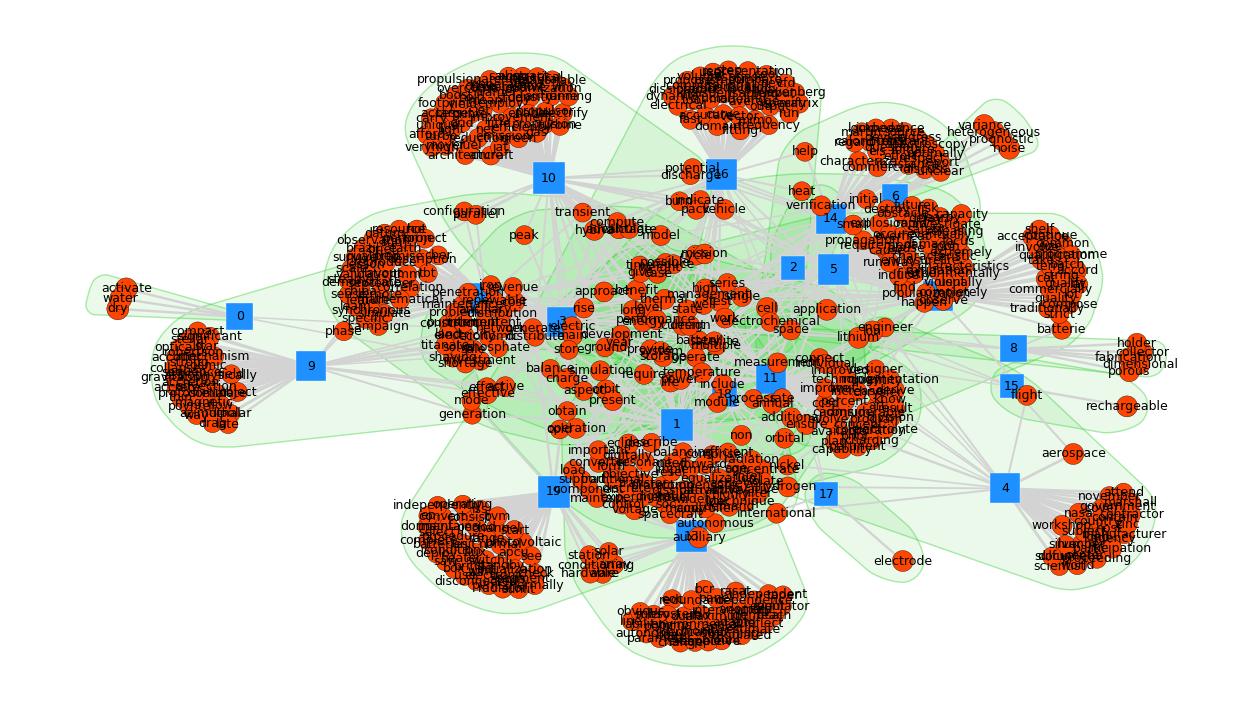

In [47]:
# Save bipartite network image
plt.figure(figsize=(14, 12))
t.plot(
    label_nodes=True,
    show_clusters=True,
    scale_nodes_by="birank",
    scale_edges_by="weight"
)
plt.savefig("document_term_network.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x1200 with 0 Axes>

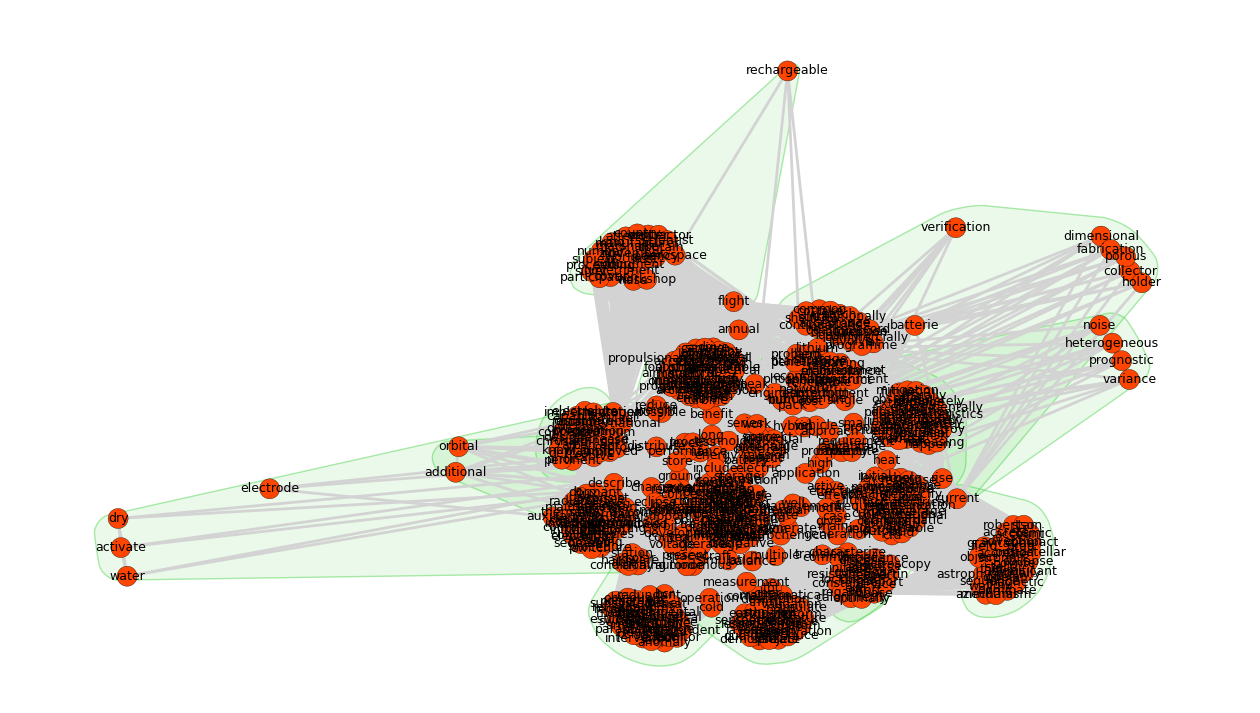

In [48]:
# Save term-term network image
plt.figure(figsize=(14, 12))
words.plot(label_nodes=True, show_clusters=True)
plt.savefig("term_term_network.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary Tables
The following tables summarize the most important nodes and relationships in the text network.

In [49]:
print("Top nodes by degree")
display(top_degree)

print("Top nodes by BiRank")
display(top_birank)

print("Top term pairs by weight")
display(top_term_pairs)

Top nodes by degree


,type,id,degree,birank
10,doc,10,87,0.036275
1,doc,1,86,0.036225
19,doc,19,83,0.036168
13,doc,13,71,0.033839
16,doc,16,66,0.033973
12,doc,12,60,0.033360
5,doc,5,60,0.033372
11,doc,11,56,0.031753
3,doc,3,48,0.031301
14,doc,14,45,0.030807


Top nodes by BiRank


,type,id,degree,birank
10,doc,10,87,0.036275
1,doc,1,86,0.036225
19,doc,19,83,0.036168
16,doc,16,66,0.033973
13,doc,13,71,0.033839
5,doc,5,60,0.033372
12,doc,12,60,0.033360
4,doc,4,39,0.031928
11,doc,11,56,0.031753
3,doc,3,48,0.031301


Top term pairs by weight


,weight,cost,source,target,source_term,target_term
22243,5.351950,0.432259,419,503,pvm,start
1496,4.607222,0.465887,23,285,aircraft,jat
9153,4.445898,0.474264,122,343,cost,network
17676,4.445898,0.474264,284,419,iss,pvm
21379,4.445898,0.474264,385,503,photovoltaic,start
9162,4.445898,0.474264,122,459,cost,revenue
6227,4.445898,0.474264,76,503,channel,start
21368,4.445898,0.474264,385,419,photovoltaic,pvm
6216,4.445898,0.474264,76,419,channel,pvm
9136,4.445898,0.474264,122,158,cost,distribution


## Task 6: Reflection

One thing that went well in this lab was that text network analysis made it easier to visualize relationships between important terms and documents. The term-term projection network was especially useful for identifying closely related concepts and thematic clusters. One challenge was interpreting network measures such as BiRank and betweenness, since they require more careful analysis than simple word frequency.

Text network analysis could be useful in my current or future research because it can help identify patterns in scientific literature. In battery research, it could be used to map relationships between terms related to materials, degradation, electrochemical performance, and space applications. It also complements topic modeling by showing direct connections among concepts.